In [1]:
!pip install nltk scikit-learn

In [2]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download NLTK stopwords
nltk.download("stopwords")

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
# STEP 3: Preprocessing Module

class PreprocessingModule:

    def __init__(self):
        self.stop_words = set(stopwords.words("english"))
        self.stemmer = PorterStemmer()

    def transform(self, text):
        # Check empty input
        if not isinstance(text, str) or not text.strip():
            raise ValueError("Input text cannot be empty.")

        # Convert to lowercase
        text = text.lower()

        # Remove numbers and symbols
        text = re.sub(r"[^a-zA-Z\s]", " ", text)

        # Remove extra spaces
        text = re.sub(r"\s+", " ", text).strip()

        # Split into words
        words = text.split()

        # Remove stopwords
        words = [
            word for word in words
            if word not in self.stop_words
        ]

        # Apply stemming
        words = [
            self.stemmer.stem(word)
            for word in words
        ]

        return " ".join(words)


# Test the preprocessing module
preprocessor = PreprocessingModule()

text = "Python is AMAZING for Data Analysis!"
result = preprocessor.transform(text)

print("Original Text:", text)
print("Processed Text:", result)

Original Text: Python is AMAZING for Data Analysis!
Processed Text: python amaz data analysi


In [4]:
# STEP 4: Vectorizer Module

class VectorizerModule:

    def __init__(self):
        self.vectorizer = TfidfVectorizer()

    def fit(self, corpus):
        self.vectorizer.fit(corpus)

    def transform(self, query):
        return self.vectorizer.transform([query])

    def transform_corpus(self, corpus):
        return self.vectorizer.transform(corpus)


# Test Vectorizer Module
vectorizer = VectorizerModule()

sample_corpus = [
    "python data analysis",
    "machine learning with python",
    "natural language processing"
]

vectorizer.fit(sample_corpus)

query_vector = vectorizer.transform("python analysis")

print("Vectorizer is working successfully!")
print("Query vector shape:", query_vector.shape)

Vectorizer is working successfully!
Query vector shape: (1, 9)


In [5]:
# STEP 5: Pipeline Class

class Pipeline:

    def __init__(self):
        self.preprocessor = PreprocessingModule()
        self.vectorizer = VectorizerModule()

    def run(self, query, corpus):

        # Check empty query
        if not query or not query.strip():
            raise ValueError("Query cannot be empty.")

        # Preprocess query
        processed_query = self.preprocessor.transform(query)

        # Preprocess all documents
        processed_corpus = [
            self.preprocessor.transform(document)
            for document in corpus
        ]

        # Fit TF-IDF
        self.vectorizer.fit(processed_corpus)

        # Convert documents into vectors
        corpus_vectors = self.vectorizer.transform_corpus(
            processed_corpus
        )

        # Convert query into vector
        query_vector = self.vectorizer.transform(
            processed_query
        )

        # Calculate cosine similarity
        scores = cosine_similarity(
            query_vector,
            corpus_vectors
        )[0]

        # Rank documents by similarity score
        ranked_results = sorted(
            enumerate(scores),
            key=lambda x: x[1],
            reverse=True
        )

        return ranked_results


print("Pipeline class created successfully!")

Pipeline class created successfully!


In [6]:
# STEP 6: Create 15-Document Corpus

corpus = [
    "Python is widely used for data analysis and machine learning.",
    "Machine learning algorithms help computers learn from data.",
    "Data analysis involves cleaning and understanding datasets.",
    "Natural language processing works with human language and text.",
    "Python provides powerful libraries for data science.",
    "Deep learning uses neural networks for complex problems.",
    "SQL is used to store and retrieve data from databases.",
    "Pandas is a Python library used for data manipulation.",
    "NumPy provides tools for numerical computing in Python.",
    "Artificial intelligence enables machines to perform intelligent tasks.",
    "Text preprocessing removes unnecessary words and symbols.",
    "TF IDF converts text into numerical vectors.",
    "Cosine similarity measures similarity between text documents.",
    "Data visualization helps users understand patterns in data.",
    "NLP can be used for sentiment analysis and text classification."
]

print("Total documents:", len(corpus))

for i, document in enumerate(corpus, start=1):
    print(f"{i}. {document}")

Total documents: 15
1. Python is widely used for data analysis and machine learning.
2. Machine learning algorithms help computers learn from data.
3. Data analysis involves cleaning and understanding datasets.
4. Natural language processing works with human language and text.
5. Python provides powerful libraries for data science.
6. Deep learning uses neural networks for complex problems.
7. SQL is used to store and retrieve data from databases.
8. Pandas is a Python library used for data manipulation.
9. NumPy provides tools for numerical computing in Python.
10. Artificial intelligence enables machines to perform intelligent tasks.
11. Text preprocessing removes unnecessary words and symbols.
12. TF IDF converts text into numerical vectors.
13. Cosine similarity measures similarity between text documents.
14. Data visualization helps users understand patterns in data.
15. NLP can be used for sentiment analysis and text classification.


In [7]:
# STEP 7: Run 5 Different Queries

pipeline = Pipeline()

queries = [
    "Python data analysis",
    "machine learning",
    "natural language processing",
    "database SQL",
    "text similarity"
]

for query in queries:

    print("\n" + "=" * 60)
    print("QUERY:", query)
    print("=" * 60)

    results = pipeline.run(query, corpus)

    print("\nTop 5 Ranked Results:\n")

    for rank, (index, score) in enumerate(results[:5], start=1):

        print(
            f"Rank {rank} | "
            f"Document {index + 1} | "
            f"Similarity Score: {score:.4f}"
        )

        print(corpus[index])
        print()


QUERY: Python data analysis

Top 5 Ranked Results:

Rank 1 | Document 1 | Similarity Score: 0.5900
Python is widely used for data analysis and machine learning.

Rank 2 | Document 3 | Similarity Score: 0.3541
Data analysis involves cleaning and understanding datasets.

Rank 3 | Document 8 | Similarity Score: 0.3383
Pandas is a Python library used for data manipulation.

Rank 4 | Document 5 | Similarity Score: 0.3246
Python provides powerful libraries for data science.

Rank 5 | Document 15 | Similarity Score: 0.2415
NLP can be used for sentiment analysis and text classification.


QUERY: machine learning

Top 5 Ranked Results:

Rank 1 | Document 2 | Similarity Score: 0.6818
Machine learning algorithms help computers learn from data.

Rank 2 | Document 1 | Similarity Score: 0.5472
Python is widely used for data analysis and machine learning.

Rank 3 | Document 6 | Similarity Score: 0.2234
Deep learning uses neural networks for complex problems.

Rank 4 | Document 10 | Similarity Score:

In [8]:
# STEP 8: Edge Case Testing

edge_cases = [
    "",
    "A",
    "12345 !!!"
]

for test_query in edge_cases:

    print("\n" + "=" * 50)
    print("Testing Query:", repr(test_query))
    print("=" * 50)

    try:
        results = pipeline.run(test_query, corpus)

        print("Top 3 Results:")

        for rank, (index, score) in enumerate(results[:3], start=1):
            print(
                f"Rank {rank} | "
                f"Document {index + 1} | "
                f"Score: {score:.4f}"
            )

    except ValueError as error:
        print("Handled Error:", error)


Testing Query: ''
Handled Error: Query cannot be empty.

Testing Query: 'A'
Top 3 Results:
Rank 1 | Document 1 | Score: 0.0000
Rank 2 | Document 2 | Score: 0.0000
Rank 3 | Document 3 | Score: 0.0000

Testing Query: '12345 !!!'
Top 3 Results:
Rank 1 | Document 1 | Score: 0.0000
Rank 2 | Document 2 | Score: 0.0000
Rank 3 | Document 3 | Score: 0.0000


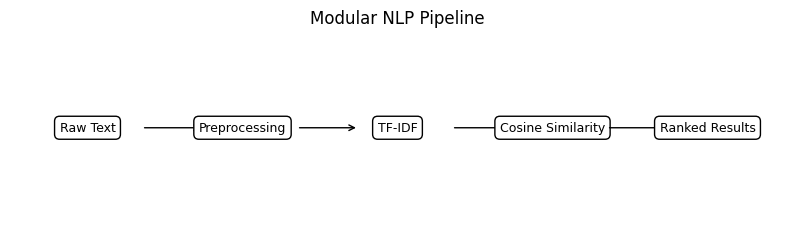

In [10]:
import matplotlib.pyplot as plt

steps = ["Raw Text", "Preprocessing", "TF-IDF", "Cosine Similarity", "Ranked Results"]

plt.figure(figsize=(10, 2.5))

for i, step in enumerate(steps):
    plt.text(i, 0, step, ha="center", va="center",
             fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="black"))

    if i < len(steps) - 1:
        plt.annotate("", (i+0.75, 0), (i+0.35, 0),
                     arrowprops=dict(arrowstyle="->"))

plt.xlim(-0.5, 4.5)
plt.ylim(-0.7, 0.7)
plt.axis("off")
plt.title("Modular NLP Pipeline", fontsize=12)

plt.savefig("architecture.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
readme = """
# Day 10 - Modular NLP Pipeline

## Objective
Build a modular NLP pipeline for text similarity and ranking.

## Modules
- PreprocessingModule
- VectorizerModule
- Pipeline

## Testing
- 15-document corpus
- 5 different queries
- Edge cases

## Flow
Raw Text -> Preprocessing -> TF-IDF -> Cosine Similarity -> Ranked Results
"""

with open("README.md", "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!
